# Project: PCA Visualization

## 0. Overview

**Problem statement:** High-dimensional data is impossible to inspect directly. Principal Component Analysis (PCA) finds the directions of maximum variance in the data and projects it to a lower-dimensional space where structure becomes visible. This project builds a complete PCA pipeline from scratch — from raw data to interactive 2D/3D visualizations — and then applies it to three progressively harder datasets to understand when PCA works, when it struggles, and why.

**Concepts from this Part:**
- ch173: SVD as the computational engine for PCA
- ch174: PCA intuition — covariance, principal directions, explained variance
- ch175: Dimensionality reduction and the curse of dimensionality
- ch179: Numerical stability (centering, scaling, rank deficiency)

**Expected output:** PCA class with fit/transform/explained_variance interface; 2D scatterplots of projected data; scree plots; biplots; variance explained curves; analysis of PCA on linearly separable vs non-linearly separable data.

**Difficulty:** Intermediate. **Estimated time:** 60–90 minutes.

---

## 1. Setup

In [1]:
# --- Setup: Imports, PCA class, and dataset generators ---

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

plt.style.use('seaborn-v0_8-whitegrid')


class PCA:
    """
    Principal Component Analysis via SVD.
    
    The standard algorithm:
    1. Center the data: X_c = X - mean(X)
    2. Optionally scale: X_s = X_c / std(X_c)
    3. Compute SVD of X_s: X_s = U Σ Vᵀ
    4. Principal components: columns of V (right singular vectors)
    5. Explained variance: σᵢ² / (n-1) for each singular value σᵢ
    
    Args:
        n_components: number of components to retain (None = all)
        scale:        if True, standardize features to unit variance
    """
    def __init__(self, n_components=None, scale=False):
        self.n_components = n_components
        self.scale = scale
        self.components_ = None          # Principal directions (n_components × n_features)
        self.explained_variance_ = None  # Variance of each component
        self.explained_variance_ratio_ = None
        self.mean_ = None
        self.std_ = None

    def fit(self, X):
        """
        Fit PCA to data X.
        Args:
            X: data matrix, shape (n_samples, n_features)
        Returns:
            self
        """
        n, p = X.shape

        # Step 1: Center
        self.mean_ = X.mean(axis=0)
        X_c = X - self.mean_

        # Step 2: Scale
        if self.scale:
            self.std_ = X_c.std(axis=0)
            self.std_[self.std_ < 1e-10] = 1.0  # prevent division by zero
            X_c = X_c / self.std_

        # Step 3: SVD of the centered (scaled) data matrix
        # Note: we use the data matrix directly (NOT the covariance matrix)
        # This avoids squaring the condition number (ch179).
        # The principal components are the right singular vectors V.
        # The explained variance of component i is s[i]^2 / (n-1).
        U, s, Vt = np.linalg.svd(X_c, full_matrices=False)

        # Step 4: Retain n_components
        k = self.n_components if self.n_components is not None else min(n, p)
        self.components_ = Vt[:k, :]             # (k, p)

        # Step 5: Explained variance
        all_var = s**2 / (n - 1)
        self.explained_variance_ = all_var[:k]
        self.explained_variance_ratio_ = all_var[:k] / all_var.sum()
        self._s = s
        return self

    def transform(self, X):
        """
        Project X onto principal components.
        Args:
            X: (n_samples, n_features)
        Returns:
            X_projected: (n_samples, n_components)
        """
        X_c = X - self.mean_
        if self.scale:
            X_c = X_c / self.std_
        return X_c @ self.components_.T

    def fit_transform(self, X):
        return self.fit(X).transform(X)

    def inverse_transform(self, X_reduced):
        """
        Reconstruct original-space approximation from projected coordinates.
        Args:
            X_reduced: (n_samples, n_components)
        Returns:
            X_reconstructed: (n_samples, n_features)
        """
        X_rec = X_reduced @ self.components_
        if self.scale:
            X_rec = X_rec * self.std_
        return X_rec + self.mean_

    def cumulative_explained_variance(self):
        """Fraction of total variance explained by top 1, 2, ... k components."""
        return np.cumsum(self.explained_variance_ratio_)


# --- Dataset generators ---

def make_gaussian_clusters(n_per_class=150, n_features=10, seed=42):
    """
    3 Gaussian clusters in 10D space, linearly separable.
    True structure lives in a 2D subspace.
    """
    rng = np.random.default_rng(seed)
    centers = np.array([[3, 0], [-2, 2], [-2, -2]])  # in 2D subspace
    # Embed into n_features dimensions via a random rotation
    basis = np.linalg.qr(rng.standard_normal((n_features, n_features)))[0][:, :2]
    X_list, y_list = [], []
    for i, center in enumerate(centers):
        pts_2d = rng.standard_normal((n_per_class, 2)) + center
        pts_hd = pts_2d @ basis.T + rng.standard_normal((n_per_class, n_features)) * 0.3
        X_list.append(pts_hd)
        y_list.append(np.full(n_per_class, i))
    return np.vstack(X_list), np.concatenate(y_list)


def make_swiss_roll(n=400, noise=0.1, seed=42):
    """Swiss roll: 1D manifold embedded in 3D. PCA cannot unroll this."""
    rng = np.random.default_rng(seed)
    t = 1.5 * np.pi * (1 + 2 * rng.uniform(0, 1, n))
    y = rng.uniform(0, 1, n)
    X = np.column_stack([
        t * np.cos(t),
        y * 10,
        t * np.sin(t)
    ]) + rng.standard_normal((n, 3)) * noise
    return X, t  # t is the "color" label showing the manifold structure


X_clusters, y_clusters = make_gaussian_clusters()
X_roll, t_roll = make_swiss_roll()

print(f"Cluster dataset: {X_clusters.shape}, {len(np.unique(y_clusters))} classes")
print(f"Swiss roll:      {X_roll.shape}")

Cluster dataset: (450, 10), 3 classes
Swiss roll:      (400, 3)


## 2. Stage 1 — PCA on Linearly Separable Data

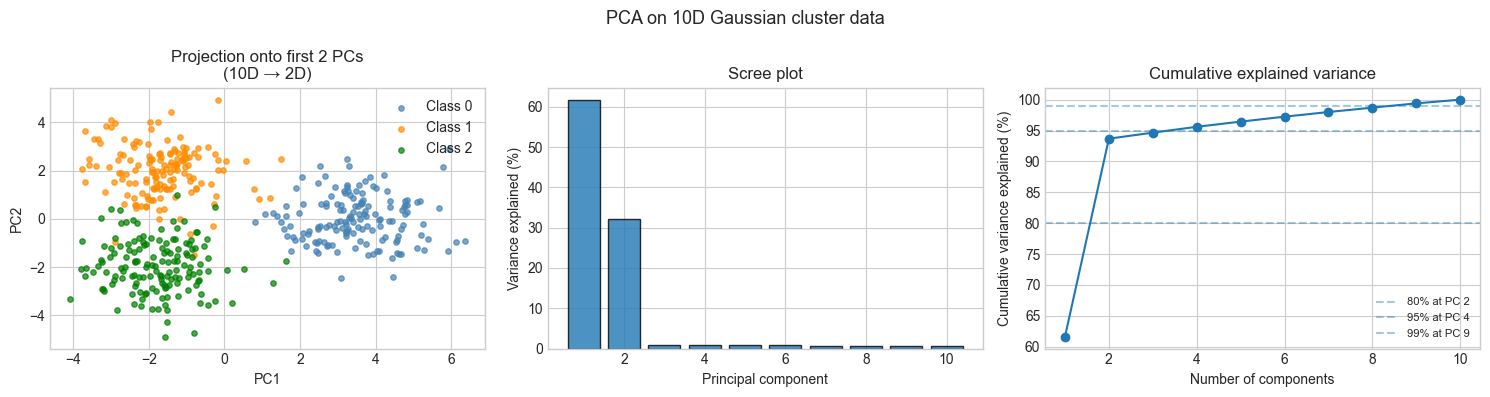

Variance explained by PC1: 61.6%
Variance explained by PC1+PC2: 93.7%
PCs needed for 95%: 4


In [2]:
# --- Stage 1: Apply PCA to the Gaussian cluster dataset ---
# The true structure lives in 2D. PCA should recover this subspace
# and produce clean class separation in the projected coordinates.

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

pca_clusters = PCA(n_components=None)  # retain all components
X_proj = pca_clusters.fit_transform(X_clusters)

CLASS_COLORS = ['steelblue', 'darkorange', 'green']
CLASS_NAMES = ['Class 0', 'Class 1', 'Class 2']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: 2D projection (PC1 vs PC2)
for i, (color, name) in enumerate(zip(CLASS_COLORS, CLASS_NAMES)):
    mask = y_clusters == i
    axes[0].scatter(X_proj[mask, 0], X_proj[mask, 1],
                    c=color, label=name, s=15, alpha=0.7)
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].set_title('Projection onto first 2 PCs\n(10D → 2D)')
axes[0].legend()

# Plot 2: Scree plot (variance explained per component)
n_all = len(pca_clusters._s)
all_var_ratio = (pca_clusters._s**2 / (pca_clusters._s**2).sum())
axes[1].bar(range(1, n_all + 1), all_var_ratio * 100, edgecolor='black', alpha=0.8)
axes[1].set_xlabel('Principal component')
axes[1].set_ylabel('Variance explained (%)')
axes[1].set_title('Scree plot')

# Plot 3: Cumulative explained variance
cum_var = np.cumsum(all_var_ratio) * 100
axes[2].plot(range(1, n_all + 1), cum_var, 'o-')
for thr in [80, 95, 99]:
    k_needed = int(np.searchsorted(cum_var, thr)) + 1
    axes[2].axhline(thr, linestyle='--', alpha=0.4, label=f'{thr}% at PC {k_needed}')
axes[2].set_xlabel('Number of components')
axes[2].set_ylabel('Cumulative variance explained (%)')
axes[2].set_title('Cumulative explained variance')
axes[2].legend(fontsize=8)

plt.suptitle('PCA on 10D Gaussian cluster data', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Variance explained by PC1: {all_var_ratio[0]*100:.1f}%")
print(f"Variance explained by PC1+PC2: {cum_var[1]:.1f}%")
print(f"PCs needed for 95%: {int(np.searchsorted(cum_var, 95)) + 1}")

## 3. Stage 2 — PCA Reconstruction and Information Loss

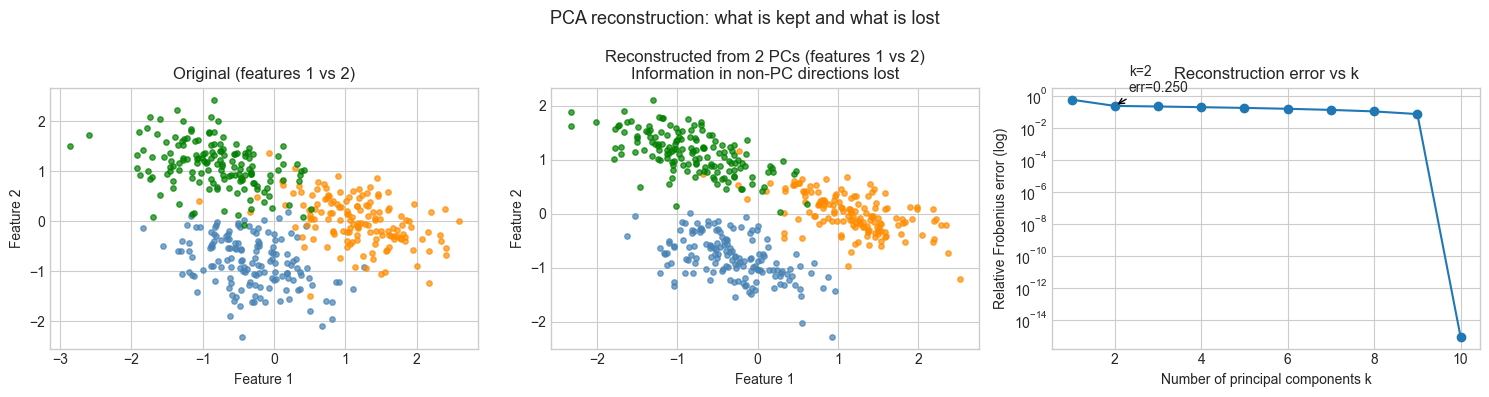

In [3]:
# --- Stage 2: Reconstruct data from principal components ---
# Project to k dimensions, reconstruct back to 10D.
# Measure reconstruction error as a function of k.
# This demonstrates what "information lost" means concretely.

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

pca_full = PCA(n_components=None)
pca_full.fit(X_clusters)

n_features = X_clusters.shape[1]
reconstruction_errors = []

for k in range(1, n_features + 1):
    pca_k = PCA(n_components=k)
    pca_k.fit(X_clusters)
    X_k = pca_k.transform(X_clusters)
    X_rec = pca_k.inverse_transform(X_k)
    err = np.linalg.norm(X_clusters - X_rec, 'fro') / np.linalg.norm(X_clusters, 'fro')
    reconstruction_errors.append(err)

# Visual: original vs reconstructed (first 3 features)
pca_2 = PCA(n_components=2)
X_2d = pca_2.fit_transform(X_clusters)
X_reconstructed = pca_2.inverse_transform(X_2d)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Original feature scatter (first 2 raw features)
for i, color in enumerate(CLASS_COLORS):
    mask = y_clusters == i
    axes[0].scatter(X_clusters[mask, 0], X_clusters[mask, 1], c=color, s=15, alpha=0.7)
axes[0].set_title('Original (features 1 vs 2)')
axes[0].set_xlabel('Feature 1'); axes[0].set_ylabel('Feature 2')

# Reconstructed feature scatter
for i, color in enumerate(CLASS_COLORS):
    mask = y_clusters == i
    axes[1].scatter(X_reconstructed[mask, 0], X_reconstructed[mask, 1], c=color, s=15, alpha=0.7)
axes[1].set_title('Reconstructed from 2 PCs (features 1 vs 2)\nInformation in non-PC directions lost')
axes[1].set_xlabel('Feature 1'); axes[1].set_ylabel('Feature 2')

# Reconstruction error vs k
axes[2].semilogy(range(1, n_features + 1), reconstruction_errors, 'o-')
axes[2].set_xlabel('Number of principal components k')
axes[2].set_ylabel('Relative Frobenius error (log)')
axes[2].set_title('Reconstruction error vs k')
# Mark k=2
axes[2].annotate(f'k=2\nerr={reconstruction_errors[1]:.3f}',
                 (2, reconstruction_errors[1]), textcoords='offset points',
                 xytext=(10, 10), arrowprops=dict(arrowstyle='->'))

plt.suptitle('PCA reconstruction: what is kept and what is lost', fontsize=13)
plt.tight_layout()
plt.show()

## 4. Stage 3 — PCA Fails on Nonlinear Structure

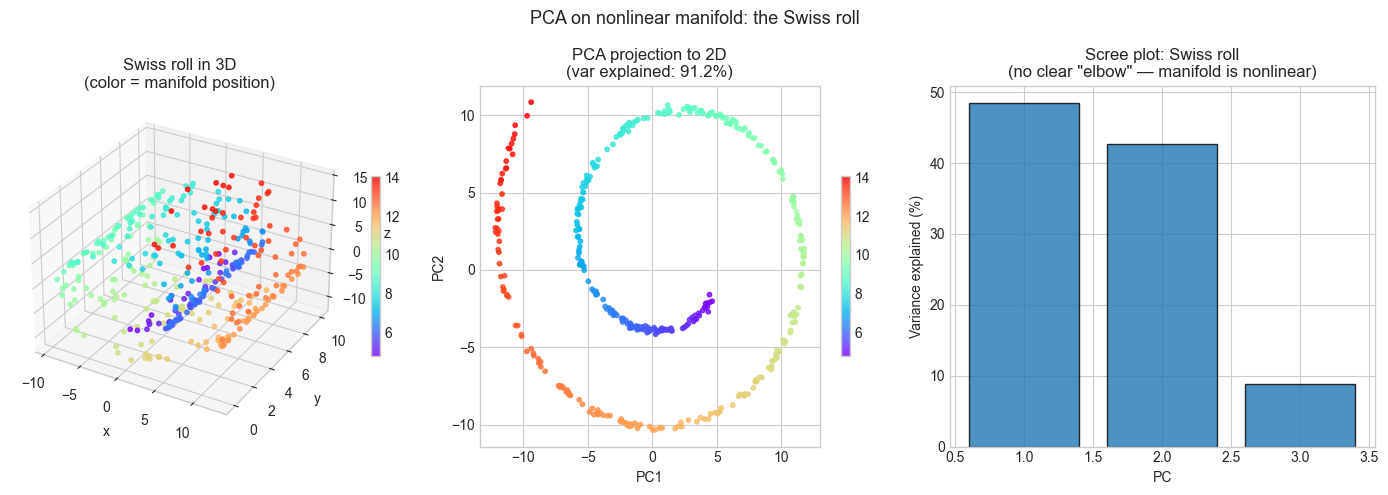

Observation:
In the PCA projection, points with very different manifold positions
(different colors) appear nearby — the roll has been 'crushed'.
PCA cannot separate them because the separation requires a nonlinear map.

Variance explained by PC1+PC2: 91.2%
High explained variance does NOT guarantee good structure preservation.


In [4]:
# --- Stage 3: Demonstrate PCA failure on nonlinear manifolds ---
# The Swiss roll is a 1D manifold (parameterized by angle t) embedded in 3D.
# PCA can only find linear projections — it cannot "unroll" the manifold.
# The projection will crumple distant points onto nearby ones.

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

pca_roll = PCA(n_components=2)
X_roll_proj = pca_roll.fit_transform(X_roll)

fig = plt.figure(figsize=(14, 5))

# 3D view of original Swiss roll
ax1 = fig.add_subplot(131, projection='3d')
sc = ax1.scatter(X_roll[:, 0], X_roll[:, 1], X_roll[:, 2],
                 c=t_roll, cmap='rainbow', s=10, alpha=0.8)
ax1.set_title('Swiss roll in 3D\n(color = manifold position)')
ax1.set_xlabel('x'); ax1.set_ylabel('y'); ax1.set_zlabel('z')
plt.colorbar(sc, ax=ax1, shrink=0.5)

# PCA projection
ax2 = fig.add_subplot(132)
sc2 = ax2.scatter(X_roll_proj[:, 0], X_roll_proj[:, 1],
                  c=t_roll, cmap='rainbow', s=10, alpha=0.8)
ax2.set_title(f'PCA projection to 2D\n(var explained: {pca_roll.cumulative_explained_variance()[-1]*100:.1f}%)')
ax2.set_xlabel('PC1'); ax2.set_ylabel('PC2')
plt.colorbar(sc2, ax=ax2, shrink=0.5)

# Scree plot for Swiss roll
ax3 = fig.add_subplot(133)
pca_roll_full = PCA(n_components=None)
pca_roll_full.fit(X_roll)
all_var_roll = pca_roll_full._s**2 / (pca_roll_full._s**2).sum()
ax3.bar(range(1, 4), all_var_roll * 100, edgecolor='black', alpha=0.8)
ax3.set_xlabel('PC'); ax3.set_ylabel('Variance explained (%)')
ax3.set_title('Scree plot: Swiss roll\n(no clear "elbow" — manifold is nonlinear)')

plt.suptitle('PCA on nonlinear manifold: the Swiss roll', fontsize=13)
plt.tight_layout()
plt.show()

print("Observation:")
print("In the PCA projection, points with very different manifold positions")
print("(different colors) appear nearby — the roll has been 'crushed'.")
print("PCA cannot separate them because the separation requires a nonlinear map.")
print(f"\nVariance explained by PC1+PC2: {pca_roll.cumulative_explained_variance()[-1]*100:.1f}%")
print("High explained variance does NOT guarantee good structure preservation.")

## 5. Stage 4 — Biplot: Interpreting Principal Components

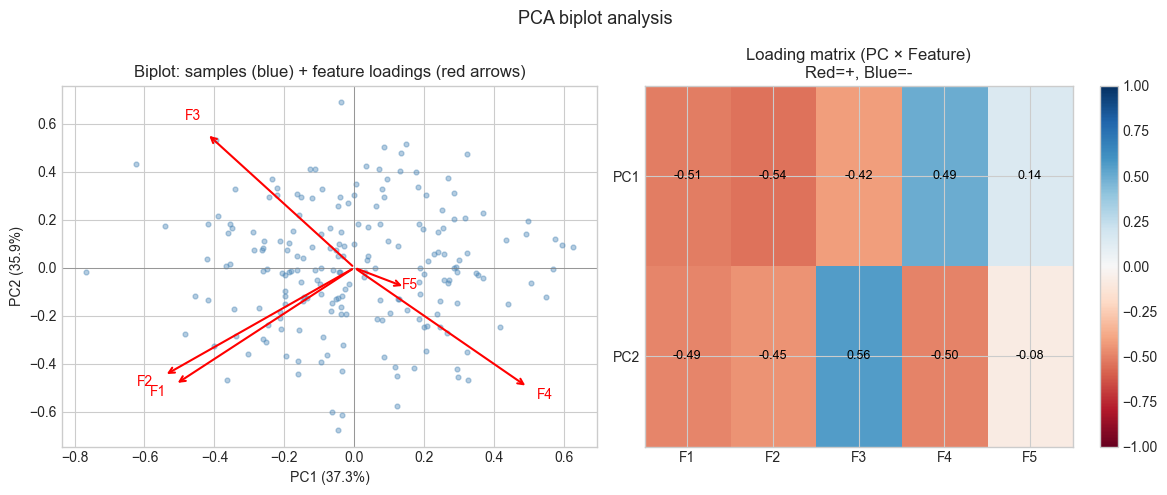

Interpretation:
- F1 and F2 point in similar directions → they load on the same PC → correlated
- F3 and F4 point in opposite directions → they are negatively correlated
- F5 (independent) points roughly orthogonally to F1-F4


In [5]:
# --- Stage 4: Biplot — visualize both samples and feature loadings ---
# A biplot overlays:
#   - Points: samples projected onto PC1 and PC2
#   - Arrows: features projected onto PC1 and PC2 (loadings)
#
# Features aligned with PC1 axis → strongly contribute to PC1 variance.
# Feature arrows pointing in same direction → positively correlated.
# Feature arrows perpendicular → uncorrelated.

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

# Use a smaller 5-feature dataset for readability
np.random.seed(7)
N_SAMPLES = 200
N_FEAT = 5

# Construct correlated data (features 0,1 correlated; 2,3 correlated; 4 independent)
t_latent = np.random.randn(N_SAMPLES)
u_latent = np.random.randn(N_SAMPLES)
X_corr = np.column_stack([
    t_latent + 0.3 * np.random.randn(N_SAMPLES),
    0.8 * t_latent + 0.5 * np.random.randn(N_SAMPLES),
    u_latent + 0.3 * np.random.randn(N_SAMPLES),
    -0.7 * u_latent + 0.4 * np.random.randn(N_SAMPLES),
    np.random.randn(N_SAMPLES)  # independent
])
feature_names = [f'F{i+1}' for i in range(N_FEAT)]

pca_biplot = PCA(n_components=2, scale=True)  # standardize for biplot
X_biplot_proj = pca_biplot.fit_transform(X_corr)

# Loadings: principal component directions in original feature space
# Shape: (n_components, n_features)
loadings = pca_biplot.components_  # each row is a PC direction

# Scale projections for display
scale = 1.0 / (X_biplot_proj.std(axis=0) * 4)
X_scaled = X_biplot_proj * scale

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Biplot
axes[0].scatter(X_scaled[:, 0], X_scaled[:, 1],
                alpha=0.4, s=12, color='steelblue', label='Samples')

ARROW_SCALE = 1.0  # adjust if arrows are too long/short
for i, feat in enumerate(feature_names):
    dx, dy = loadings[0, i] * ARROW_SCALE, loadings[1, i] * ARROW_SCALE
    axes[0].annotate('', xy=(dx, dy), xytext=(0, 0),
                     arrowprops=dict(arrowstyle='->', color='red', lw=1.5))
    axes[0].text(dx * 1.1, dy * 1.1, feat, color='red', fontsize=10, ha='center')

axes[0].axhline(0, color='gray', linewidth=0.5)
axes[0].axvline(0, color='gray', linewidth=0.5)
axes[0].set_xlabel(f'PC1 ({pca_biplot.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca_biplot.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].set_title('Biplot: samples (blue) + feature loadings (red arrows)')

# Loading heatmap
im = axes[1].imshow(loadings, cmap='RdBu', vmin=-1, vmax=1, aspect='auto')
axes[1].set_xticks(range(N_FEAT))
axes[1].set_xticklabels(feature_names)
axes[1].set_yticks([0, 1])
axes[1].set_yticklabels(['PC1', 'PC2'])
axes[1].set_title('Loading matrix (PC × Feature)\nRed=+, Blue=-')
plt.colorbar(im, ax=axes[1])

# Annotate loadings on heatmap
for i in range(2):
    for j in range(N_FEAT):
        axes[1].text(j, i, f'{loadings[i,j]:.2f}',
                     ha='center', va='center', fontsize=9, color='black')

plt.suptitle('PCA biplot analysis', fontsize=13)
plt.tight_layout()
plt.show()

print("Interpretation:")
print("- F1 and F2 point in similar directions → they load on the same PC → correlated")
print("- F3 and F4 point in opposite directions → they are negatively correlated")
print("- F5 (independent) points roughly orthogonally to F1-F4")

## 6. Results & Reflection

### What was built

A complete PCA implementation with:
- `fit` / `transform` / `inverse_transform` interface
- Optional feature scaling (standardization)
- Explained variance and cumulative variance tracking
- Applied to three scenarios: linearly separable high-dimensional data, reconstruction quality analysis, and nonlinear manifold failure mode
- Biplot visualization connecting principal components to original feature loadings

### What math made it possible

- **SVD on data matrix vs covariance matrix (ch179):** Computing SVD of the *data matrix* X (not XᵀX) preserves numerical precision. The eigendecomposition of XᵀX squares the condition number, making it less stable.
- **Eckart-Young theorem (ch173):** The truncated SVD gives the best rank-k approximation in the Frobenius norm, which is why PCA minimizes reconstruction error among all linear projections.
- **Orthogonality of principal components:** The rows of V are orthonormal — the projection is distance-preserving within the retained subspace (no distortion of inter-point distances in the PC space).
- **PCA is a linear method (ch164):** It finds optimal linear subspaces. For data that lies on a nonlinear manifold (Swiss roll), linear projection inevitably folds distant points onto nearby ones.

### Extension challenges

1. **Robust PCA:** Standard PCA is sensitive to outliers (a single extreme point can dominate the first principal component). Implement a "robustified" PCA that identifies and downweights points far from the PC subspace, then compare the resulting components on a dataset with 5% randomly inserted outliers.

2. **Kernel PCA:** The PCA in this project is linear. Implement a simplified kernel PCA that: (a) computes the pairwise kernel matrix K[i,j] = exp(-‖xᵢ - xⱼ‖²/σ²), (b) double-centers K, (c) eigendecomposes K. Apply it to the Swiss roll and compare the 2D projection to linear PCA. *(Hint: the Swiss roll should unroll significantly)*

3. **PCA for anomaly detection:** Fit PCA on "normal" data. For new data points, compute the reconstruction error ‖x - PCA_reconstruct(x)‖. Points with large reconstruction error lie outside the normal subspace and are anomalies. Test this on the Gaussian cluster dataset by injecting 20 artificial outliers at random positions far from all clusters.